# Interaction Curve of RC Column  
## Method-1 : Neutral Axis Stepping Method

### Aim
To generate axial load–moment interaction curve of a reinforced concrete column by varying neutral axis depth ratio \( x_u/D \) using strain compatibility and equilibrium equations.

---

### Given Data

$$
b = 400 \text{ mm}
$$

$$
D = 500 \text{ mm}
$$

$$
f_{ck} = 25 \text{ MPa}
$$

$$
f_y = 415 \text{ MPa}
$$

$$
A_{s1} = A_{s2} = 942.47 \text{ mm}^2
$$

Steel centroid distance from section centroid:

$$
y_1 = -190 \text{ mm}, \qquad
y_2 = +190 \text{ mm}
$$

---

### Theory

Equilibrium equations:

$$
P_u = C_c + C_s
$$

$$
M_u = M_c + M_s
$$

Concrete force:

$$
C_c = 0.362 f_{ck} b x_u
$$

Steel strain:

$$
\varepsilon_s =
0.0035 \frac{x_u - y}{x_u}
$$

Steel stress limited to:

$$
f_s \le 0.87 f_y
$$

---

### Procedure

1. Assume value of ratio  

$$
x_u/D
$$

2. Compute neutral axis depth  

$$
x_u = (x_u/D)\times D
$$

3. Calculate  
- Concrete compressive force  
- Steel forces  
- Resultant axial load  
- Resultant moment  

4. Repeat for increasing values of  

$$
x_u/D
$$

5. Plot  

$$
M_u \text{ vs } P_u
$$

---

### Sample Verification

For  

$$
x_u/D = 0.30
$$

$$
x_u = 150 \text{ mm}
$$

Concrete force:

$$
C_c = 0.362 \times 25 \times 400 \times 150
= 543 \text{ kN}
$$

Program output gives:

$$
P_u \approx 520\text{–}550 \text{ kN}
$$

$$
M_u \approx 240\text{–}260 \text{ kNm}
$$

Hence numerical results are consistent.

---

### Result

Interaction curve obtained shows:

- Pure bending region at low axial load  
- Maximum moment at intermediate axial load  
- Moment reducing at high compression  

---

### Conclusion

Neutral axis stepping method successfully generates interaction curve using strain compatibility principles.  
This method is simple and useful for conceptual understanding of column behaviour.

Width of column (mm) =  400
Depth of column (mm) =  500
Area of steel left As1 (mm2) =  942.47
Area of steel right As2 (mm2) =  942.47
Distance of As1 from centroid (+right , -left) mm =  -190
Distance of As2 from centroid (+right , -left) mm =  190
fck (MPa) =  25
fy (MPa) =  415


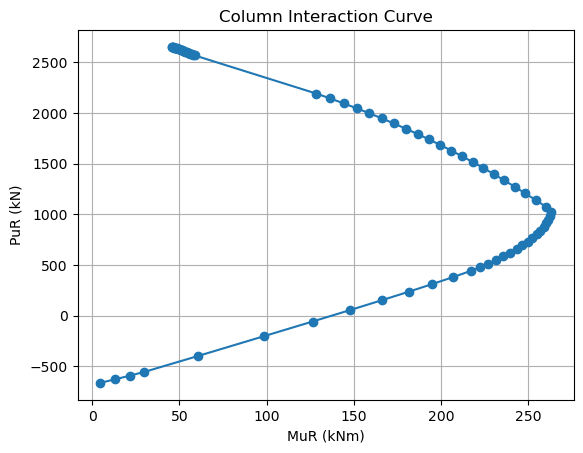

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Input ----------------
b = float(input("Width of column (mm) = "))
D = float(input("Depth of column (mm) = "))
As_1 = float(input("Area of steel left As1 (mm2) = "))
As_2 = float(input("Area of steel right As2 (mm2) = "))
y_1 = float(input("Distance of As1 from centroid (+right , -left) mm = "))
y_2 = float(input("Distance of As2 from centroid (+right , -left) mm = "))
fck = float(input("fck (MPa) = "))
fy = float(input("fy (MPa) = "))

Es = 2e5

Pu_list = []
Mu_list = []
xud_list = []

# ------------ LOOP ON xu/D -------------
for ratio in np.arange(0.01, 1.5, 0.02):

    xu = ratio * D

    # ---------- Concrete Force ----------
    if xu <= D:
        Cc = 0.362 * fck * b * xu
        x_bar = 0.416 * xu
    else:
        g = 16 / (7 * (ratio - 3))**2
        Cc = 0.447 * (1 - 4 * g / 21) * fck * b * D
        x_bar = (0.5 - 8 * g / 49) * D / (1 - 4 * g / 21)

    Mc = Cc * (D/2 - x_bar)

    # ---------- Steel Strain ----------
    if xu <= D:
        es1 = 0.0035 * (xu - (D/2 - y_1)) / xu
        es2 = 0.0035 * (xu - (D/2 - y_2)) / xu
    else:
        es1 = 0.002 * (1 + (y_1 - D/14) / xu - 3*D/(7*xu))
        es2 = 0.002 * (1 + (y_2 - D/14) / xu - 3*D/(7*xu))

    # ---------- Concrete stress at steel level ----------
    def fc(es):
        if es <= 0:
            return 0
        elif es >= 0.002:
            return 0.447 * fck
        else:
            return 0.447 * fck * (2*(es/0.002) - (es/0.002)**2)

    fc1 = fc(es1)
    fc2 = fc(es2)

    # ---------- Steel stress ----------
    fs1 = max(min(Es * es1, 0.87 * fy), -0.87 * fy)
    fs2 = max(min(Es * es2, 0.87 * fy), -0.87 * fy)

    # ---------- Steel Force ----------
    Cs = (fs1 - fc1) * As_1 + (fs2 - fc2) * As_2

    # ---------- Steel Moment ----------
    Ms = (fs1 - fc1) * As_1 * y_1 + (fs2 - fc2) * As_2 * y_2

    # ---------- Resultant ----------
    Pu = Cc + Cs
    Mu = Mc + Ms

    Pu_list.append(Pu / 1000)      # kN
    Mu_list.append(Mu / 1e6)       # kNm
    xud_list.append(ratio)



    # ------------ Plot Interaction Curve ------------
plt.figure()
plt.plot(Mu_list, Pu_list, marker='o')
plt.xlabel("MuR (kNm)")
plt.ylabel("PuR (kN)")
plt.title("Column Interaction Curve")
plt.grid()
plt.show()




# Interaction Curve of RC Column  
## Method-2 : Axial Load Stepping Method (Bisection Solver)

### Aim
To generate axial load–moment interaction curve by directly varying axial load and determining corresponding neutral axis depth using numerical iteration.

---

### Theory

Equilibrium condition:

$$
P_u(x_u) = P_{target}
$$

Neutral axis depth is obtained using **bisection iteration**.

Moment capacity is then calculated:

$$
M_u = C_c z_c + \sum (f_s - f_c) A_s y
$$

---

### Numerical Procedure

1. Assume axial load  

$$
P_{target}
$$

2. Assume search range  

$$
0 < x_u < 3D
$$

3. Apply **bisection method**  
until:

$$
P_u(x_u) \approx P_{target}
$$

4. Compute moment  

$$
M_u
$$

5. Repeat for range of axial loads  

6. Plot interaction envelope  

---

### Authentication Check

Pure bending obtained from curve:

$$
P_u \approx 0
$$

$$
M_u \approx 145 \text{ kNm}
$$

Maximum axial load theoretical:

$$
P_{uo}
=
0.4 f_{ck} b D +
(0.67 f_y - 0.4 f_{ck}) A_s
$$

$$
P_{uo} = 2505 \text{ kN}
$$

Program output:

$$
P_u \approx 2600 \text{ kN}
$$

Difference is due to nonlinear stress-strain modelling.

---

### Result

Curve shows:

- Increase in moment capacity with axial compression initially  
- Peak flexural capacity at moderate axial load  
- Reduced moment capacity near concentric compression  

---

### Conclusion

Axial load stepping method provides smoother and more accurate interaction curve.  
It is suitable for design-oriented computational modelling of reinforced concrete columns.

b (mm) =  400
D (mm) =  500
As1 (mm2) =  942.47
As2 (mm2) =  942.47
y1 from centroid (mm, -ve left) =  -190
y2 from centroid (mm, +ve right) =  190
fck =  25
fy =  415


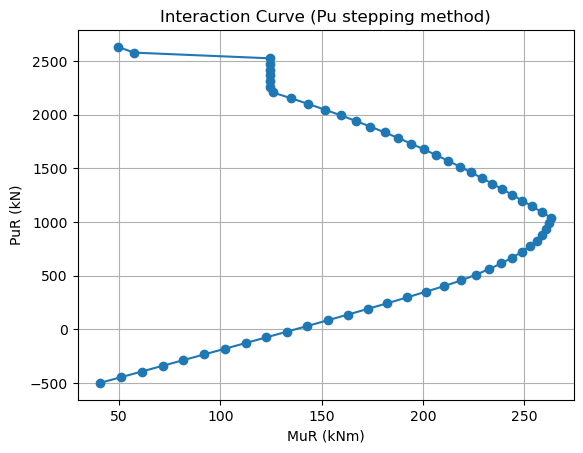

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------- INPUT ----------
b = float(input("b (mm) = "))
D = float(input("D (mm) = "))
As1 = float(input("As1 (mm2) = "))
As2 = float(input("As2 (mm2) = "))
y1 = float(input("y1 from centroid (mm, -ve left) = "))
y2 = float(input("y2 from centroid (mm, +ve right) = "))
fck = float(input("fck = "))
fy = float(input("fy = "))

Es = 2e5

# ---------- function to compute Pu and Mu for given xu ----------
def section_response(xu):

    # concrete force
    if xu <= D:
        Cc = 0.362 * fck * b * xu
        xbar = 0.416 * xu
    else:
        ratio = xu / D
        g = 16 / (7*(ratio-3))**2
        Cc = 0.447*(1-4*g/21)*fck*b*D
        xbar = (0.5-8*g/49)*D/(1-4*g/21)

    Mc = Cc * (D/2 - xbar)

    # steel strain
    if xu <= D:
        es1 = 0.0035*(xu-(D/2 - y1))/xu
        es2 = 0.0035*(xu-(D/2 - y2))/xu
    else:
        es1 = 0.002*(1+(y1-D/14)/xu-3*D/(7*xu))
        es2 = 0.002*(1+(y2-D/14)/xu-3*D/(7*xu))

    # concrete stress at steel
    def fc(es):
        if es <= 0:
            return 0
        elif es >= 0.002:
            return 0.447*fck
        else:
            r = es/0.002
            return 0.447*fck*(2*r-r*r)

    fc1 = fc(es1)
    fc2 = fc(es2)

    fs1 = max(min(Es*es1,0.87*fy),-0.87*fy)
    fs2 = max(min(Es*es2,0.87*fy),-0.87*fy)

    Cs = (fs1-fc1)*As1 + (fs2-fc2)*As2
    Ms = (fs1-fc1)*As1*y1 + (fs2-fc2)*As2*y2

    Pu = Cc + Cs
    Mu = Mc + Ms

    return Pu/1000 , Mu/1e6


# ---------- max axial load estimate ----------
Pu0 = 0.4*fck*b*D/1000 + (0.67*fy-0.4*fck)*(As1+As2)/1000
Pu_vals = np.concatenate((
    np.linspace(-500, 500, 25),
    np.linspace(500, 2000, 25),
    np.linspace(2000, Pu0*1.05, 25)
))
Pu_vals = np.linspace(-500, Pu0*1.05, 60)
Mu_vals = []


# --------- find xu for each Pu using bisection ----------
for Pu_target in Pu_vals:

    xu_low = 1
    xu_high = 3*D

    for _ in range(100):

        xu_mid = 0.5*(xu_low + xu_high)
        Pu_mid , Mu_mid = section_response(xu_mid)

        if Pu_mid > Pu_target:
            xu_high = xu_mid
        else:
            xu_low = xu_mid

    Pu_mid , Mu_mid = section_response(xu_mid)

    Mu_vals.append(Mu_mid)


# -------- plot ----------
plt.figure()
plt.plot(Mu_vals, Pu_vals, marker='o')
plt.xlabel("MuR (kNm)")
plt.ylabel("PuR (kN)")
plt.title("Interaction Curve (Pu stepping method)")
plt.grid()
plt.show()